In [1]:
import numpy as np

In [5]:
import pandas as pd

df = pd.read_csv('/content/online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.shape

(12330, 18)

In [7]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [9]:
# Missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [10]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [11]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

In [12]:
for column in df.columns:
    print(column, ":", df[column].nunique())

Administrative : 27
Administrative_Duration : 3335
Informational : 17
Informational_Duration : 1258
ProductRelated : 311
ProductRelated_Duration : 9551
BounceRates : 1872
ExitRates : 4777
PageValues : 2704
SpecialDay : 6
Month : 10
OperatingSystems : 8
Browser : 13
Region : 9
TrafficType : 20
VisitorType : 3
Weekend : 2
Revenue : 2


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 125


In [14]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','bool']).columns

# Fill numerical columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [16]:
# Label Encoding for categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [17]:
# Drop Revenue column from feature set
X = df.drop("Revenue", axis=1)

# Target variable (used later for evaluation)
y = df["Revenue"]

print("Feature Shape:", X.shape)

Feature Shape: (12330, 17)


In [18]:
scaler = StandardScaler()

num_cols = X.select_dtypes(include=['int64','float64']).columns

X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,-1.233426,-0.790293,-0.894178,-0.762629,0.407786,-0.550552
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,-1.334959,-0.136078,-0.207952,-0.894178,-0.514182,0.407786,-0.550552
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,2.058618,-0.790293,2.437081,-0.265735,0.407786,-0.550552
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,-1.334959,0.961270,-0.207952,-0.477771,-0.017289,0.407786,-0.550552
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,-1.334959,0.961270,0.374389,-0.894178,-0.017289,0.407786,1.816360


In [19]:
# Final dataset shape
print("Final Dataset Shape:", X.shape)

# Feature names
print("\nFeature Names:")
print(list(X.columns))

# Sample preprocessed rows
print("\nSample Preprocessed Rows:")
print(X.head())

Final Dataset Shape: (12330, 17)

Feature Names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Sample Preprocessed Rows:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   
2       -0.696993                -0.457191      -0.396478   
3       -0.696993                -0.457191      -0.396478   
4       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   
2               -0.244931       -0.691003                -0.624348

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors



In [21]:
print("Dataset shape:", X.shape)
print("Feature names:")
print(X.columns)

X.head()

Dataset shape: (12330, 17)
Feature names:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='object')


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,-1.233426,-0.790293,-0.894178,-0.762629,0.407786,-0.550552
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,-1.334959,-0.136078,-0.207952,-0.894178,-0.514182,0.407786,-0.550552
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,2.058618,-0.790293,2.437081,-0.265735,0.407786,-0.550552
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,-1.334959,0.961270,-0.207952,-0.477771,-0.017289,0.407786,-0.550552
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,-1.334959,0.961270,0.374389,-0.894178,-0.017289,0.407786,1.816360


# **Elbow Method**

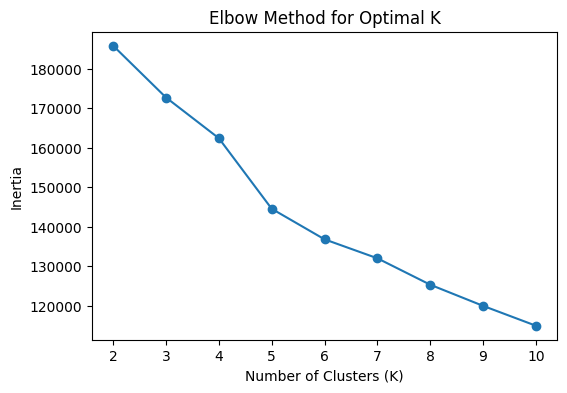

In [22]:
inertia = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

# **Silhouette**

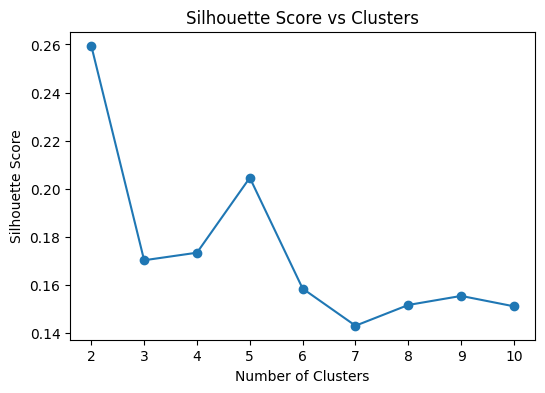

In [23]:
sil_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Clusters")
plt.show()

In [24]:
k = 4   # example value, adjust based on elbow/silhouette result

kmeans = KMeans(n_clusters=k, random_state=42)

kmeans_labels = kmeans.fit_predict(X)

print("Silhouette Score:", silhouette_score(X, kmeans_labels))

Silhouette Score: 0.1734835846905057


# **DBSCAN**

In [25]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

db_labels = dbscan.fit_predict(X)

print("Unique clusters:", np.unique(db_labels))

if len(set(db_labels)) > 1:
    print("Silhouette Score:", silhouette_score(X, db_labels))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70
 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94
 95 96 97]
Silhouette Score: -0.33096672757949297


# **Agglomerative**

In [26]:
agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X)

print("Silhouette Score:", silhouette_score(X, agg_labels))

Silhouette Score: 0.1535594599142164


# **Spectral(K-Nearest)**

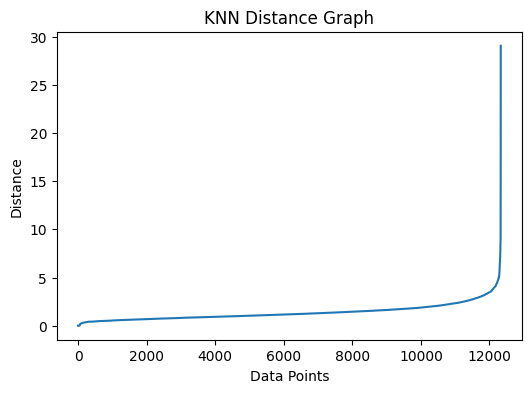

In [27]:
neighbors = NearestNeighbors(n_neighbors=10)

neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("KNN Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [28]:
spectral = SpectralClustering(
    n_clusters=4,
    affinity='nearest_neighbors',
    random_state=42
)

spec_labels = spectral.fit_predict(X)

print("Spectral Clustering Silhouette Score:",
      silhouette_score(X, spec_labels))

Spectral Clustering Silhouette Score: 0.1268310486957991


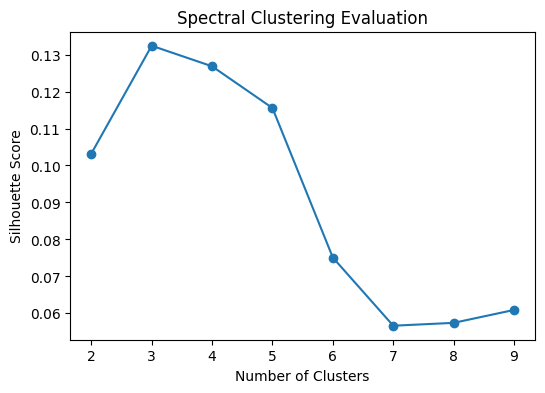

In [29]:
scores = []
cluster_range = range(2,10)

for k in cluster_range:

    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        random_state=42
    )

    labels = spectral.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(cluster_range, scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Spectral Clustering Evaluation")

plt.show()

In [30]:
cluster_results = X.copy()

cluster_results["KMeans_Cluster"] = kmeans_labels
cluster_results["DBSCAN_Cluster"] = db_labels
cluster_results["Agglomerative_Cluster"] = agg_labels
cluster_results["Spectral_Cluster"] = spec_labels

cluster_results.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,KMeans_Cluster,DBSCAN_Cluster,Agglomerative_Cluster,Spectral_Cluster
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-1.233426,-0.790293,-0.894178,-0.762629,0.407786,-0.550552,2,0,3,3
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.136078,-0.207952,-0.894178,-0.514182,0.407786,-0.550552,2,1,0,0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,2.058618,-0.790293,2.437081,-0.265735,0.407786,-0.550552,2,-1,3,3
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,0.961270,-0.207952,-0.477771,-0.017289,0.407786,-0.550552,2,-1,0,0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,0.961270,0.374389,-0.894178,-0.017289,0.407786,1.816360,2,-1,0,0


In [31]:
print("K-Means Cluster Counts")
print(pd.Series(kmeans_labels).value_counts())

print("\nDBSCAN Cluster Counts")
print(pd.Series(db_labels).value_counts())

print("\nAgglomerative Cluster Counts")
print(pd.Series(agg_labels).value_counts())

print("\nSpectral Cluster Counts")
print(pd.Series(spec_labels).value_counts())

K-Means Cluster Counts
2    7991
1    1673
3    1656
0    1010
Name: count, dtype: int64

DBSCAN Cluster Counts
-1     8427
 1     1162
 2      434
 16     279
 12     165
       ... 
 67       5
 87       5
 93       5
 8        4
 75       2
Name: count, Length: 99, dtype: int64

Agglomerative Cluster Counts
0    8995
1    1911
3     783
2     641
Name: count, dtype: int64

Spectral Cluster Counts
0    10092
1     1622
3      564
2       52
Name: count, dtype: int64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA

In [33]:
results = {}

# K-Means
results["KMeans"] = [
    silhouette_score(X, kmeans_labels),
    davies_bouldin_score(X, kmeans_labels),
    calinski_harabasz_score(X, kmeans_labels)
]

# DBSCAN (ignore noise points)
mask = db_labels != -1
results["DBSCAN"] = [
    silhouette_score(X[mask], db_labels[mask]),
    davies_bouldin_score(X[mask], db_labels[mask]),
    calinski_harabasz_score(X[mask], db_labels[mask])
]

# Agglomerative
results["Agglomerative"] = [
    silhouette_score(X, agg_labels),
    davies_bouldin_score(X, agg_labels),
    calinski_harabasz_score(X, agg_labels)
]

# Spectral
results["Spectral"] = [
    silhouette_score(X, spec_labels),
    davies_bouldin_score(X, spec_labels),
    calinski_harabasz_score(X, spec_labels)
]

In [34]:
evaluation_df = pd.DataFrame(
    results,
    index=[
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ]
).T

print("Clustering Evaluation Metrics")
evaluation_df

Clustering Evaluation Metrics


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
KMeans,0.173484,1.935534,1195.934171
DBSCAN,0.054578,1.107050,153.254205
Agglomerative,0.153559,1.966307,1184.175032
Spectral,0.126831,1.496758,781.846412


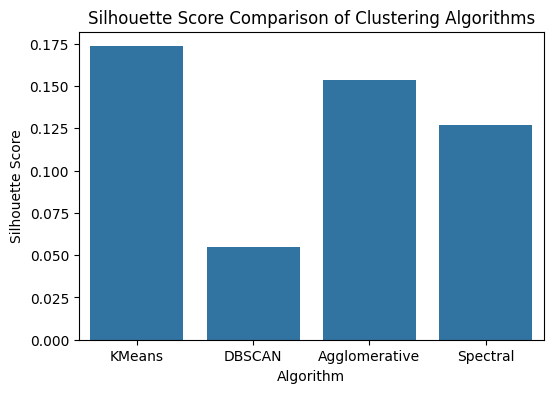

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=evaluation_df.index,
    y=evaluation_df["Silhouette Score"]
)

plt.title("Silhouette Score Comparison of Clustering Algorithms")
plt.ylabel("Silhouette Score")
plt.xlabel("Algorithm")

plt.show()

In [36]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.20093093 0.10573323]


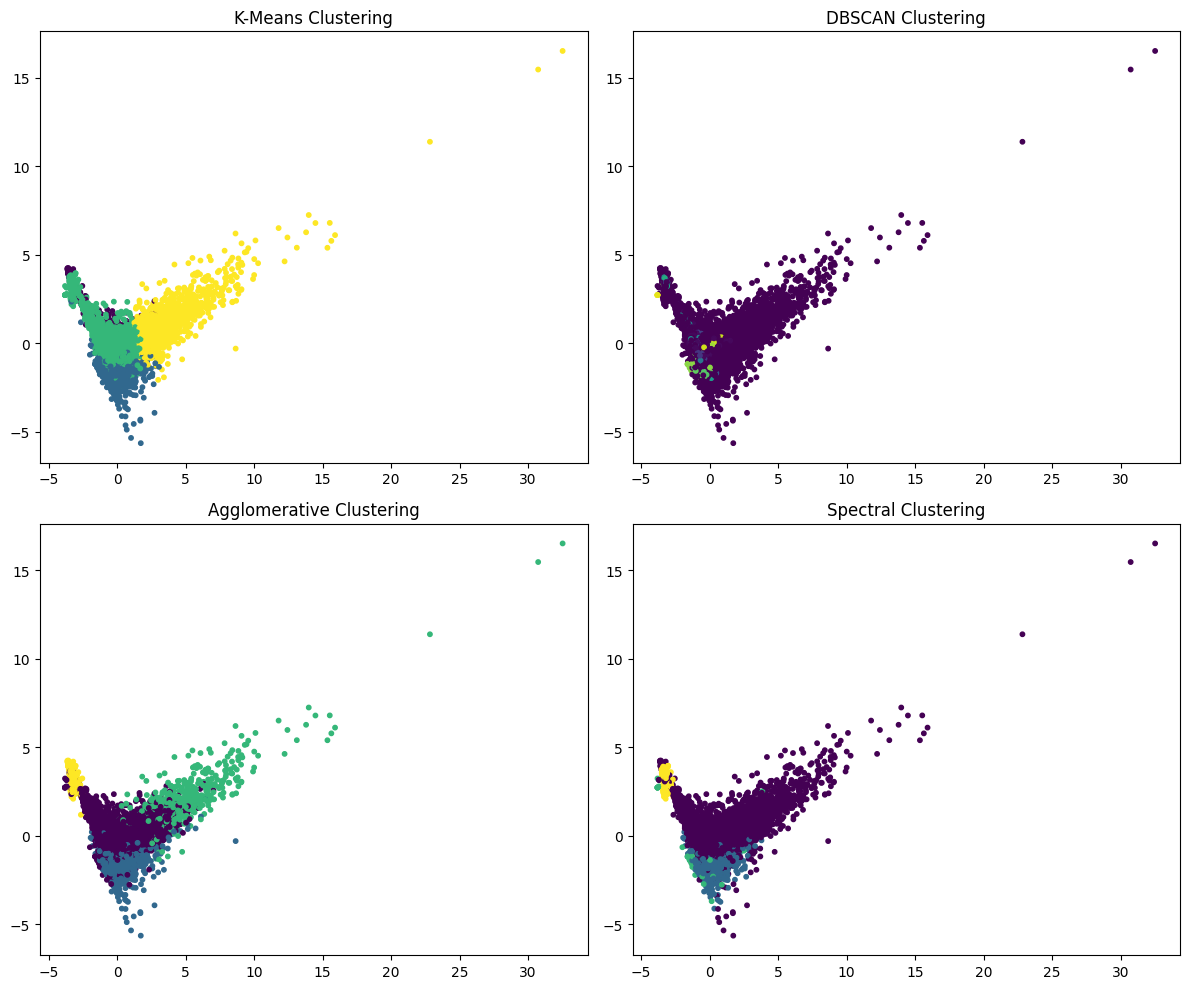

In [37]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

# KMeans
axes[0,0].scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=10)
axes[0,0].set_title("K-Means Clustering")

# DBSCAN
axes[0,1].scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='viridis', s=10)
axes[0,1].set_title("DBSCAN Clustering")

# Agglomerative
axes[1,0].scatter(X_pca[:,0], X_pca[:,1], c=agg_labels, cmap='viridis', s=10)
axes[1,0].set_title("Agglomerative Clustering")

# Spectral
axes[1,1].scatter(X_pca[:,0], X_pca[:,1], c=spec_labels, cmap='viridis', s=10)
axes[1,1].set_title("Spectral Clustering")

plt.tight_layout()
plt.show()

In [38]:
best_algorithm = evaluation_df["Silhouette Score"].idxmax()

print("Best Clustering Algorithm Based on Silhouette Score:")
print(best_algorithm)

Best Clustering Algorithm Based on Silhouette Score:
KMeans


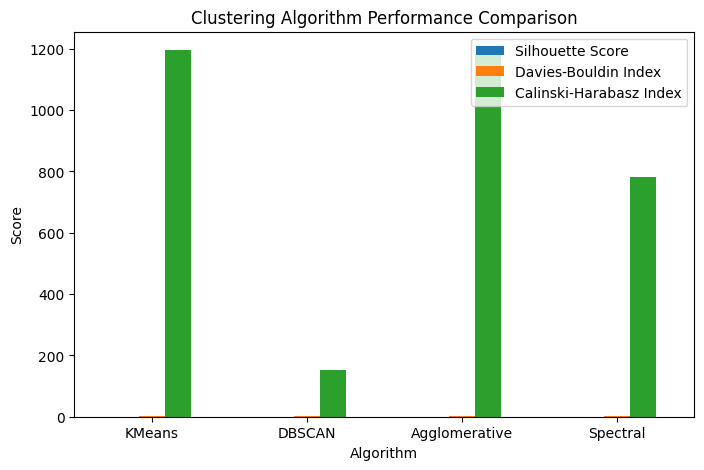

In [39]:
evaluation_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Clustering Algorithm Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Algorithm")
plt.xticks(rotation=0)

plt.show()